In [1]:
# LIBRARIES IMPORT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#LOAD DATA & MAP SPECIES NAMES

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [3]:
#FIRST 5 ROWS INSPECTION

print("Iris Dataset Overview:")
print()
print(df.head())

Iris Dataset Overview:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [4]:
#STATISTICAL SUMMARY

print("Dataset statistical summary:")
print()
print(df.describe())

Dataset statistical summary:

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [5]:
#DATA QUALITY CHECK

print("Missing Values:")
print()
print(df.isnull().sum())

Missing Values:

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


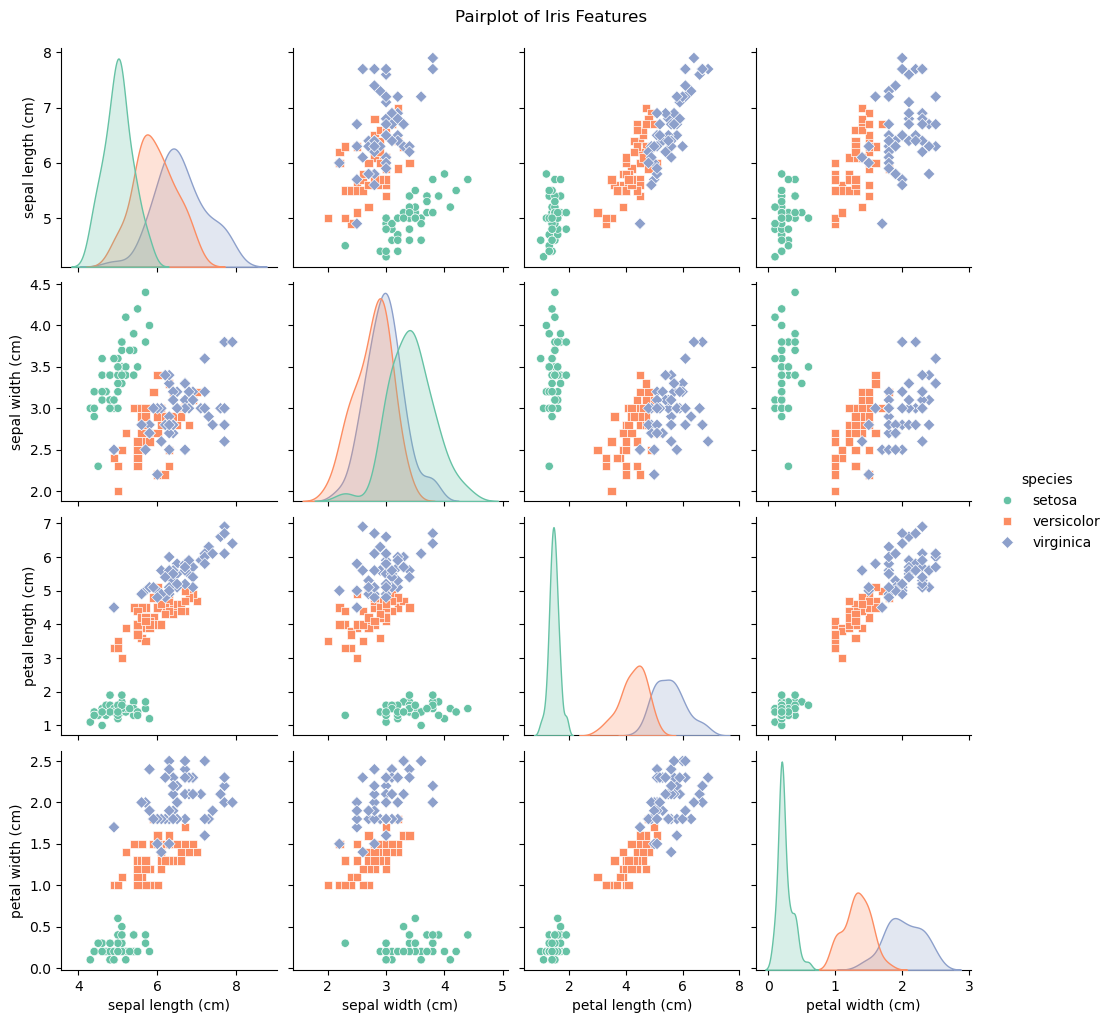

In [6]:
#FEATURE RELATIONSHIPS VISUALIZATION

df['species'] = [iris.target_names[i] for i in iris.target]
sns.pairplot(df, hue='species', markers=["o", "s", "D"], palette='Set2')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

In [7]:
#TRAIN/TEST DATA SPLITTING

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
#MULTIPLE MODELS TRAINING & EVALUATION

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='linear', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    print("=" * 50)
    print(f"Model: {name} | Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))
    
    results.append({"Model": name, "Accuracy (%)": round(acc * 100, 2)})

# comparison table
comparison_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False)
print("=" * 50)
print("Model Comparison:")
print(comparison_df.to_string(index=False))

Model: Logistic Regression | Accuracy: 93.33%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Model: Random Forest | Accuracy: 90.00%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Model: Support Vector Machine | Accuracy: 100.00%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00    

In [10]:
#SOFT VOTING ENSEMBLE CLASSIFIER

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=200)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('svm', SVC(kernel='linear', probability=True, random_state=42))
    ],
    voting='soft'  
)

voting_clf.fit(X_train_scaled, y_train)
y_pred_ensemble = voting_clf.predict(X_test_scaled)

print("=" * 50)
print(f"Merged Ensemble Accuracy: {accuracy_score(y_test, y_pred_ensemble) * 100:.2f}%")
print("=" * 50)
print("\nClassification Report (Ensemble):")
print(classification_report(y_test, y_pred_ensemble, target_names=iris.target_names))

Merged Ensemble Accuracy: 93.33%

Classification Report (Ensemble):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



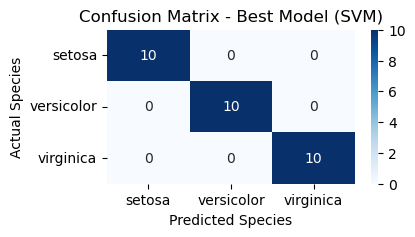

In [11]:
#CONFUSION MATRIX HEATMAP

best_model = models["Support Vector Machine"]
y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title("Confusion Matrix - Best Model (SVM)")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

In [12]:
# HARD VOTING & MULTI-MODEL PREDICTION

from collections import Counter
voting_hard = VotingClassifier(
    estimators=[
        ('lr', models["Logistic Regression"]),
        ('dt', models["Decision Tree"]),
        ('rf', models["Random Forest"]),
        ('svm', models["Support Vector Machine"])
    ],
    voting='hard'
)
voting_hard.fit(X_train_scaled, y_train)
models["Voting Classifier (Hard)"] = voting_hard

# Sample Dataset for Testing
new_sample = [[3.5, 3.5, 4.5, 4.5]]
new_sample_scaled = scaler.transform(new_sample)

predictions_list = []
individual_votes = []

for name, model in models.items():
    pred_idx = model.predict(new_sample_scaled)[0]
    pred_species = iris.target_names[pred_idx].capitalize()
    if hasattr(model, "predict_proba"):
        prob = np.max(model.predict_proba(new_sample_scaled)) * 100
        confidence = f"{prob:.1f}%"
    else:
        confidence = "N/A (Majority Vote)"
        
    predictions_list.append({
        "Model": name,
        "Predicted Class": pred_species,
        "Score": confidence
    })
    
    if "Voting" not in name:
        individual_votes.append(pred_species)

pred_df = pd.DataFrame(predictions_list)
vote_counts = Counter(individual_votes)
majority_class, majority_count = vote_counts.most_common(1)[0]
total_base_models = len(individual_votes)

# Final Output
print("=" * 40)
print("SAMPLE PREDICTION ANALYSIS")
print("=" * 40)
print(f"Input Measurements:")
print(f" • Sepal Length: {new_sample[0][0]} cm | Sepal Width: {new_sample[0][1]} cm")
print(f" • Petal Length: {new_sample[0][2]} cm | Petal Width: {new_sample[0][3]} cm")
print("-" * 60)
print("Individual & Ensemble Model Predictions:")
print(pred_df.to_string(index=False))
print("-" * 60)
print("Final Prediction Decision:")
print(f" • Final Predicted Species : {majority_class.upper()}")
print(f" • Model Consensus         : {majority_count}/{total_base_models} models agree ({majority_count/total_base_models*100:.0f}%)")
print("=" * 60)

SAMPLE PREDICTION ANALYSIS
Input Measurements:
 • Sepal Length: 3.5 cm | Sepal Width: 3.5 cm
 • Petal Length: 4.5 cm | Petal Width: 4.5 cm
------------------------------------------------------------
Individual & Ensemble Model Predictions:
                   Model Predicted Class               Score
     Logistic Regression       Virginica              100.0%
           Random Forest       Virginica               63.0%
  Support Vector Machine       Virginica              100.0%
           Decision Tree      Versicolor              100.0%
Voting Classifier (Hard)       Virginica N/A (Majority Vote)
------------------------------------------------------------
Final Prediction Decision:
 • Final Predicted Species : VIRGINICA
 • Model Consensus         : 3/4 models agree (75%)
